In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/jawadwali/fraud-detection/creditcard (1).csv


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score, precision_recall_curve
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load dataset (place creditcard.csv in same folder)
df = pd.read_csv('/kaggle/input/datasets/jawadwali/fraud-detection/creditcard (1).csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
df.shape, df['Class'].value_counts()

((284807, 31),
 Class
 0    284315
 1       492
 Name: count, dtype: int64)

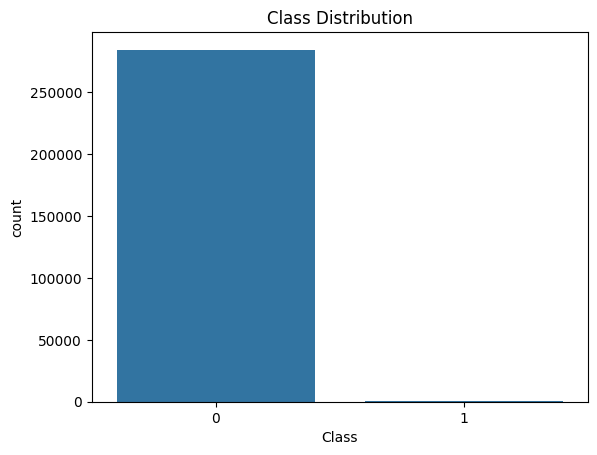

Fraud Percentage: 0.173%


In [6]:
# Class imbalance
sns.countplot(x='Class', data=df)
plt.title('Class Distribution')
plt.show()

fraud_pct = df['Class'].mean()*100
print(f'Fraud Percentage: {fraud_pct:.3f}%')

In [ ]:
# Feature Engineering
df['Amount_Scaled'] = StandardScaler().fit_transform(df[['Amount']])
df = df.drop(columns=['Amount'])  # Time can be kept or dropped
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape, X_test.shape)

In [8]:
# Apply SMOTE on training data
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)
print('Before:', y_train.value_counts().to_dict())
print('After :', pd.Series(y_train_sm).value_counts().to_dict())

Before: {0: 227451, 1: 394}
After : {0: 227451, 1: 227451}


In [17]:
def evaluate_model(model, Xtr, ytr, Xte, yte, name):
    model.fit(Xtr, ytr)
    pred = model.predict(Xte)
    proba = model.predict_proba(Xte)[:,1] if hasattr(model,'predict_proba') else pred

    print('='*60)
    print(name)
    print(confusion_matrix(yte, pred))
    print(classification_report(yte, pred, digits=4))
    print('ROC-AUC :', round(roc_auc_score(yte, proba),4))
    print('PR-AUC  :', round(average_precision_score(yte, proba),4))

In [ ]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000)
evaluate_model(lr, X_train_sm, y_train_sm, X_test, y_test, 'Logistic Regression')

In [ ]:
# KNN (sampled training for speed if needed)
knn = KNeighborsClassifier(n_neighbors=5)
evaluate_model(knn, X_train_sm, y_train_sm, X_test, y_test, 'KNN')

In [ ]:
# Naive Bayes
nb = GaussianNB()
evaluate_model(nb, X_train_sm, y_train_sm, X_test, y_test, 'Gaussian Naive Bayes')